In [1]:
from src import DataPreprocessor

# Load the data
file_path = 'datasets/mall_customers.csv'
preprocessor = DataPreprocessor(file_path)
df = preprocessor.load_data()
head, info = preprocessor.inspect_data()

print("Data Head:")
print(head)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
Data Head:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


#### Παρατηρούμε:
    Έχουμε μικρό dataset (200 εγγραφές).Θα πρέπει να το έχουμε υπ'όψη γιατί θα επηρεάσει την εγκυρότητα των μοντέλων
    Δεν χρειάζεται να ελέγξουμε για null values.
#### Θα εξαλείψουμε τυχόν περίεργες τιμές και outliers, εστιάζοντας στις στήλες Annual Income και Spending Score

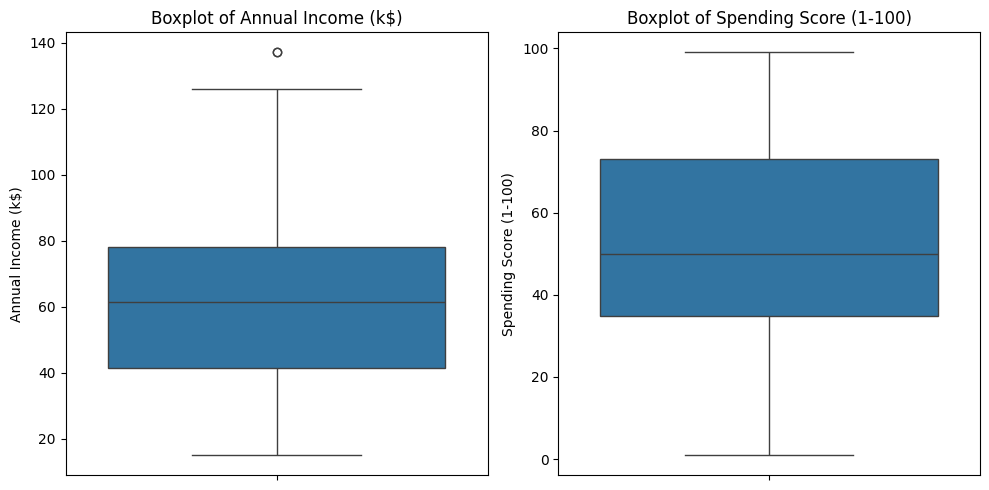

Original Row Count: 200
Rows Removed: 2
Current Row Count: 198
Outliers were detected and removed.


In [2]:
# Columns to check
cols_to_check = ['Annual Income (k$)', 'Spending Score (1-100)']

# 1. Visualize first (to see if there are "crazy" outliers)
preprocessor.plot_boxplots(cols_to_check)

# 2. Remove outliers
df_clean = preprocessor.remove_outliers(cols_to_check)

# We calculate the removed count
original_count = 200 # or len(preprocessor.data)
removed_count = original_count - len(df_clean)

print(f"Original Row Count: {original_count}")
print(f"Rows Removed: {removed_count}")
print(f"Current Row Count: {len(df_clean)}")

if removed_count > 0:
    print("Outliers were detected and removed.")
else:
    print("No outliers detected based on 1.5 IQR threshold.")

#### Παρατηρούμε πως διαγράφηκαν 2 εγγραφές.
    Τη μία απο αυτές την βλέπουμε και στο πρώτο boxplot. Πρόκειται για πολύ υψηλή τιμή  εισοδήματος.
#### Στη συνέχεια θα κάνουμε feature selection.
    Πρώτα θα υπολογίσουμε το correlation coefficient μεταξύ Age, Gender και Spending Score. Μετά θα αποφασίσουμε αν θα συμπεριλάβουμε
    τα Age, Gender στη διαδικασία του clustering.

Correlation Matrix:
                             Age  Gender_Num  Spending Score (1-100)
Age                     1.000000   -0.067835               -0.329421
Gender_Num             -0.067835    1.000000                0.059092
Spending Score (1-100) -0.329421    0.059092                1.000000


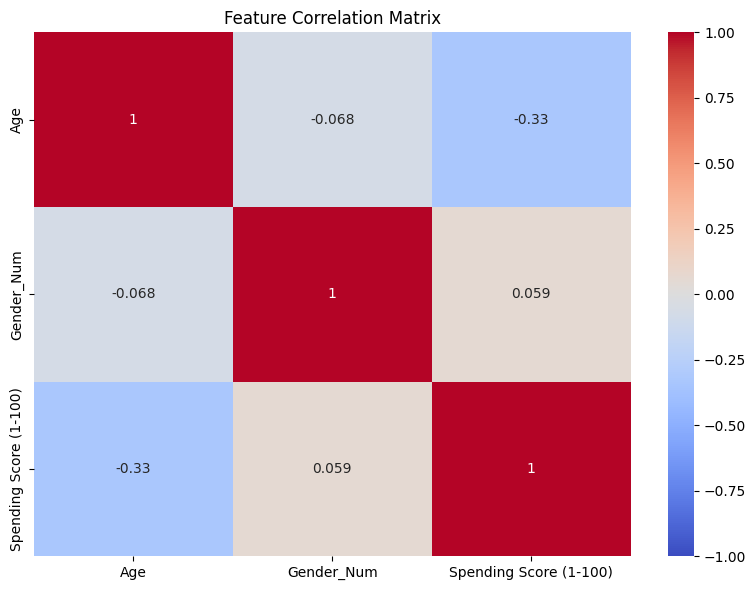

In [3]:
from  src import FeatureAnalyzer

analyzer = FeatureAnalyzer(df_clean)

# Map gender to 0 for 'Male' and 1 for 'Female'
analyzer.encode_categorical()

# Columns: Age, Gender (Encoded), Spending Score
cols_to_analyze = ['Age', 'Gender_Num', 'Spending Score (1-100)']

corr_matrix = analyzer.compute_correlations(cols_to_analyze)
analyzer.plot_heatmap(corr_matrix)

print("Correlation Matrix:")
print(corr_matrix)

#### Παρατηρήσεις:
    - Age vs. Spending Score (-0.33). Η ηλικία παρουσιάζει ελαφρώς αρνητική συσχέτιση με το Spending Score. Αυτό μας δείχνει πως
      οι νεότερες ηλικίες συνηθίζουν να ξοδεύουν περισσότερα χρήματα κατά μέσο όρο. Είναι σημαντικό εύρημα.
    - Gender vs. Spending Score (0.06). Η συσχέτιση μεταξύ φύλου και spending score είναι σχεδόν μηδενική.
#### Βασιζόμενοι στα ανωτέρω ευρήματα θα συμπεριλάβουμε την ηλικία στη διαδικασία του clustering

Optimization for 3 Features (Scaled):
K | Inertia | Silhouette
2 | 385.28 | 0.3341
3 | 292.20 | 0.3564
4 | 202.70 | 0.4057
5 | 164.21 | 0.4212
6 | 128.64 | 0.4338
7 | 112.22 | 0.4243
8 | 98.95 | 0.4124
9 | 87.42 | 0.4210
10 | 79.50 | 0.4233

Best K based on Silhouette: 6

Model trained with k=6 on Scaled Data.
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        5  
1        5  
2        3  
3        5  
4        3  


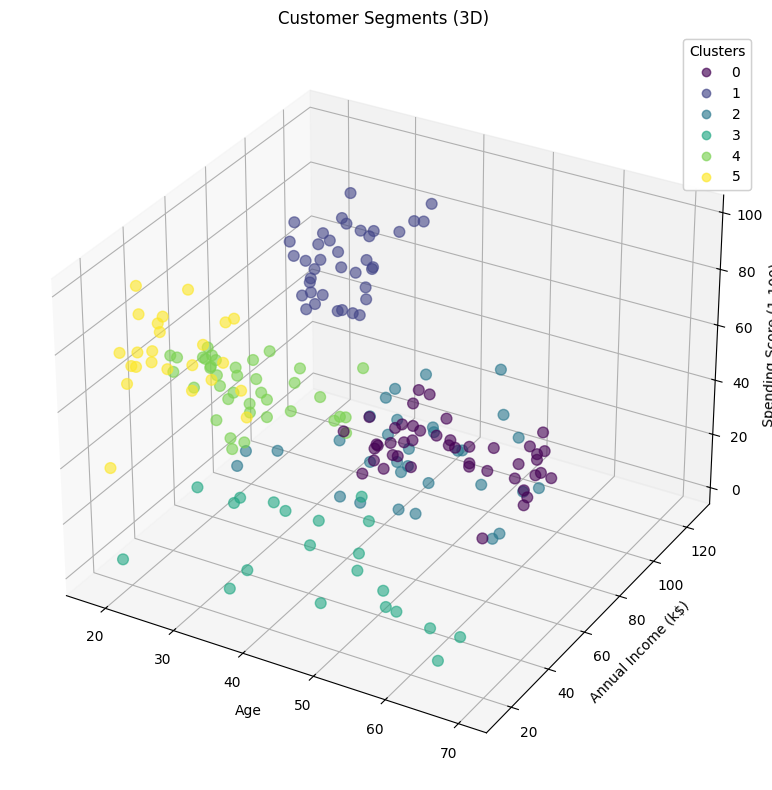

In [4]:
from src import ClusterVisualizer
from src import ClusterModeler
# Features to use
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Get Scaled Data for Modeling
X_scaled = preprocessor.get_scaled_features(features)

# Find optimal K for this new feature set
modeler = ClusterModeler(X_scaled)
inertia, silhouette = modeler.find_optimal_k()

# Print the scores to pick k programmatically or visually
print("Optimization for 3 Features (Scaled):")
print("K | Inertia | Silhouette")
best_k = 2
best_sil = -1
for k, i, s in zip(modeler.k_range, inertia, silhouette):
    print(f"{k} | {i:.2f} | {s:.4f}")
    if s > best_sil:
        best_sil = s
        best_k = k

print(f"\nBest K based on Silhouette: {best_k}")

# Train Final Model
labels = modeler.train_model(best_k)

# Visualize (using Original Data for axis readability)
# We need the cleaned dataframe from preprocessor
df_clean = preprocessor.df_clean.copy()
df_clean['Cluster'] = labels

visualizer = ClusterVisualizer()
visualizer.plot_clusters_3d(df_clean, labels, features)

print(f"\nModel trained with k={best_k} on Scaled Data.")
print(df_clean.head())
